In [34]:
from typing import List,TypedDict
import time
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
load_dotenv()

True

In [35]:
docs=(
    PyPDFLoader(r"./documents/book1 (1).pdf").load() +
    PyPDFLoader(r"./documents/book2 (1).pdf").load() + 
    PyPDFLoader(r"./documents/book3 (1).pdf").load()
)

In [36]:
len(docs)

2123

In [37]:
chunks=RecursiveCharacterTextSplitter(chunk_size=900,chunk_overlap=150).split_documents(docs)

for d in chunks:
    d.page_content=d.page_content.encode("utf-8","ignore").decode("utf-8","ignore")

In [38]:
len(chunks)

6685

In [39]:
from sentence_transformers import SentenceTransformer
from langchain_huggingface import HuggingFaceEmbeddings
import warnings
warnings.filterwarnings("ignore")

embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)

In [40]:
vectorstore=FAISS.from_documents(chunks,embeddings)

In [41]:
retriever=vectorstore.as_retriever(search_type="similarity",search_kwargs={'k':4})

In [42]:
llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash",api_key=os.getenv("GOOGLE_API_KEY"))

In [43]:
class State(TypedDict):
    question:str
    docs:List[Document]
    answer:str

In [44]:
def retriever_node(state):
    q=state["question"]
    return {'docs':retriever.invoke(q)}

In [45]:
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context, say you don't know."),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)
def generate_node(state):
    context = "\n\n".join(d.page_content for d in state["docs"])
    out = (prompt | llm).invoke({"question": state["question"], "context": context})
    return {"answer": out.content}

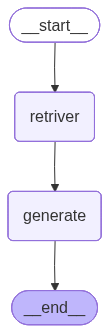

In [46]:
g=StateGraph(State)
g.add_node("retriver",retriever_node)
g.add_node("generate",generate_node)
g.add_edge(START,"retriver")
g.add_edge("retriver","generate")
g.add_edge("generate",END)
app=g.compile()
app

In [47]:
res = app.invoke({"question": "WHat is a transformer in deep learning.", "docs": [], "answer": ""})
print(res["answer"])

Based on the context provided, the text mentions "All transformers also have a convenience method called fit_transform()", but it does not define what a transformer is in deep learning.


In [48]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

CHAPTER 1. INTRODUCTION
1.2.1 The Many Names and Changing Fortunes of Neural Net-
works
We expect that many readers of this book have heard of deep learning as an
exciting new technology, and are surprised to see a mention of “history” in a book
about an emerging ﬁeld. In fact, deep learning dates back to the 1940s. Deep
learning only appears to be new, because it was relatively unpopular for several
years preceding its current popularity, and because it has gone through many
diﬀerent names, and has only recently become called “deep learning.” The ﬁeld
has been rebranded many times, reﬂecting the inﬂuence of diﬀerent researchers
and diﬀerent perspectives.
A comprehensive history of deep learning is beyond the scope of this textbook.
However, some basic context is useful for understanding deep learning. Broadly
speaking, there have been three waves of development of deep learning: deep
****************************************************************************************************
T